In [6]:
countrycode_file_path= r"C:\修論研究\VWT_historical_data\country_list.xlsx"
import pandas as pd
countrycode_df = pd.read_excel(countrycode_file_path)
countrycode_df.head()


,Country name,FAO code,Position,Reporting,Discontinuities,ISO3
0,Afghanistan,2,1,1,NaN,AFG
1,Albania,3,2,1,NaN,ALB
2,Algeria,4,3,1,NaN,DZA
3,American Samoa,5,4,0,NaN,ASM
4,Andorra,6,5,0,NaN,AND


VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_2015.npy
Importer index: 114 (iso3=JPN)

Top sources (iso3, import):
    iso3        import
237  USA  4.975250e+09
39   CAN  1.698768e+09
12   AUS  1.687919e+09
233  UKR  1.924913e+08
235  GBR  2.343775e+07
187  RUS  1.282198e+07
86   DEU  1.043869e+07
186  ROU  9.304388e+06
125  LVA  8.582511e+06
79   FRA  3.538479e+06
228  TUR  1.299862e+05
112  ITA  6.785547e+04
159  NLD  3.630733e+04
111  ISR  7.495711e+03
106  IND  6.938494e+03
178  PER  2.844793e+03
216  SWE  1.653635e+03
221  THA  1.301140e+03
world iso key: ISO_A3 (fixed)


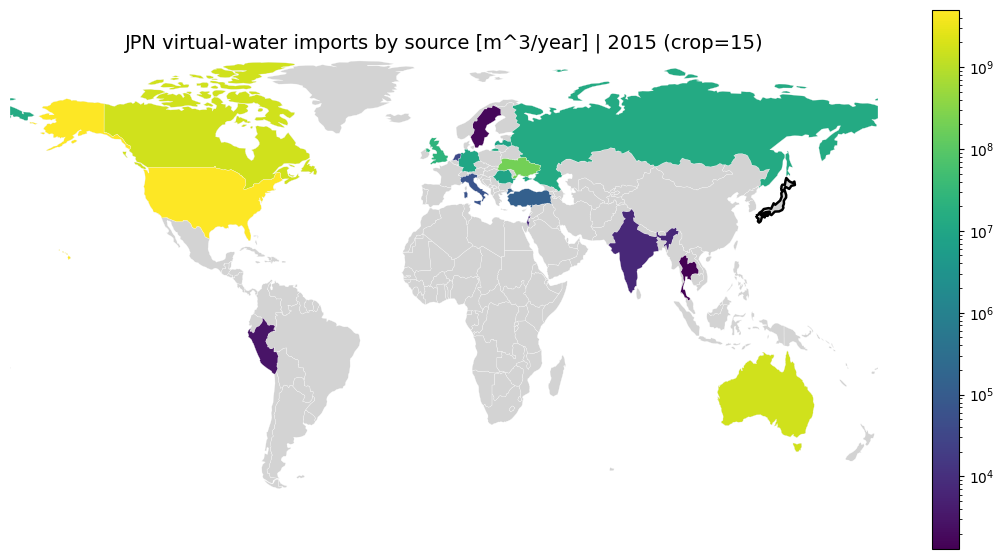

In [7]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def _normalize_zip_shp_path(p: str) -> str:
    # "xxx.zip!yyy.shp" -> "zip://xxx.zip!yyy.shp"
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def plot_vwt_imports_by_source(
    importer_iso3: str,
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,   # 例: r"...\VWT_npy\VWT_{crop}_{year}.npy"
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    use_log=True,
    top_n_print=20,
    unit="m^3/year",
):
    """
    VWTmat: row=exporter, col=importer 前提。
    importer_iso3 を固定して「どこから輸入しているか（輸出元の分布）」を地図で表示する。
    """

    importer_iso3 = str(importer_iso3).strip().upper()

    # -------------------------
    # 1) Load VWT matrix
    # -------------------------
    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    VWTmat = np.load(vwt_path).astype(float)

    N = VWTmat.shape[0]
    if VWTmat.shape[0] != VWTmat.shape[1]:
        print(f"[WARN] VWTmat is not square: {VWTmat.shape}. row/colの向きを要確認")

    print("VWTmat shape:", VWTmat.shape)
    print("VWT file:", vwt_path)

    # -------------------------
    # 2) Load country list
    # -------------------------
    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
            iso3_col = c
            break
    if iso3_col is None:
        for c in cl.columns:
            if "iso3" in str(c).strip().lower():
                iso3_col = c
                break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    # importer index を ISO3で決める
    hit = clN.index[clN["_iso3"] == importer_iso3]
    if len(hit) == 0:
        raise ValueError(
            f"importer_iso3={importer_iso3} が country_list の先頭N行に見つからない。\n"
            f"・country_listがVWT順になっているか\n"
            f"・ISO3列の中身が正しいか\n"
            f"・importer_iso3の表記(USA/JPNなど)が正しいか を確認して。"
        )
    importer_index = int(hit[0])
    print("Importer index:", importer_index, f"(iso3={importer_iso3})")

    # -------------------------
    # 3) Import vector (sources)
    # -------------------------
    # ★列を抜く：各輸出元(exporter) -> importer への流量
    imports = VWTmat[:, importer_index].astype(float)

    src = pd.DataFrame({"iso3": clN["_iso3"].values, "import": imports})
    src_pos = src[src["import"] > 0].sort_values("import", ascending=False)

    print("\nTop sources (iso3, import):")
    print(src_pos.head(top_n_print))

    # -------------------------
    # 4) Load world map (ISO_A3 固定)
    # -------------------------
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world["_iso3"] = world["ISO_A3"].astype(str).str.strip().str.upper()
    world.loc[world["_iso3"].isin(["-99", "NAN", "NONE", ""]), "_iso3"] = np.nan

    print("world iso key: ISO_A3 (fixed)")

    # -------------------------
    # 5) Merge
    # -------------------------
    m = world.merge(src, left_on="_iso3", right_on="iso3", how="left")

    # -------------------------
    # 6) Plot
    # -------------------------
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(
        f"{importer_iso3} virtual-water imports by source [{unit}] | {year} (crop={crop})",
        fontsize=14
    )

    # base
    m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

    pos = m["import"].fillna(0) > 0
    if pos.any():
        if use_log:
            vmin = m.loc[pos, "import"].min()
            vmax = m.loc[pos, "import"].max()
            m.loc[pos].plot(
                ax=ax,
                column="import",
                norm=LogNorm(vmin=vmin, vmax=vmax),
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
        else:
            m.loc[pos].plot(
                ax=ax,
                column="import",
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
    else:
        print("[WARN] import > 0 が1つも無い（向きが逆、year/cropが違う等を疑う）")

    # highlight importer boundary
    tgt = m[m["_iso3"] == importer_iso3]
    if len(tgt) > 0:
        tgt.boundary.plot(ax=ax, linewidth=1.8, color="black")
    else:
        print("[WARN] importer が地図側で見つからない（ISO_A3にその国が無い/特殊コードの可能性）")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return src_pos, m


# =========================
# 使い方（ここだけ変えればOK）
# =========================
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

src_pos, merged_map = plot_vwt_imports_by_source(
    importer_iso3="JPN",
    year=2015,
    crop=15,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    use_log=True,
    top_n_print=20,
)

# 30年のアニメーションをつくりたい。（国、作物）ソ連崩壊以前のロシアなど反映されていないことに注意

MovieWriter ffmpeg unavailable; using Pillow instead.


Importer index: 114 (iso3=JPN)
N: 255
Global scale: vmin=488.241, vmax=7.78054e+09 (use_log=True)

Top sources in first frame:
    iso3        import
237  USA  7.510733e+09
12   AUS  2.540696e+09
39   CAN  1.950486e+09
46   HKG  9.456649e+05

Top sources in first frame:
    iso3        import
237  USA  7.510733e+09
12   AUS  2.540696e+09
39   CAN  1.950486e+09
46   HKG  9.456649e+05
Saved GIF: C:\修論研究\VWT_historical_data\JPN_crop15_1986_2016_import.gif

Top sources in first frame:
    iso3        import
237  USA  7.510733e+09
12   AUS  2.540696e+09
39   CAN  1.950486e+09
46   HKG  9.456649e+05


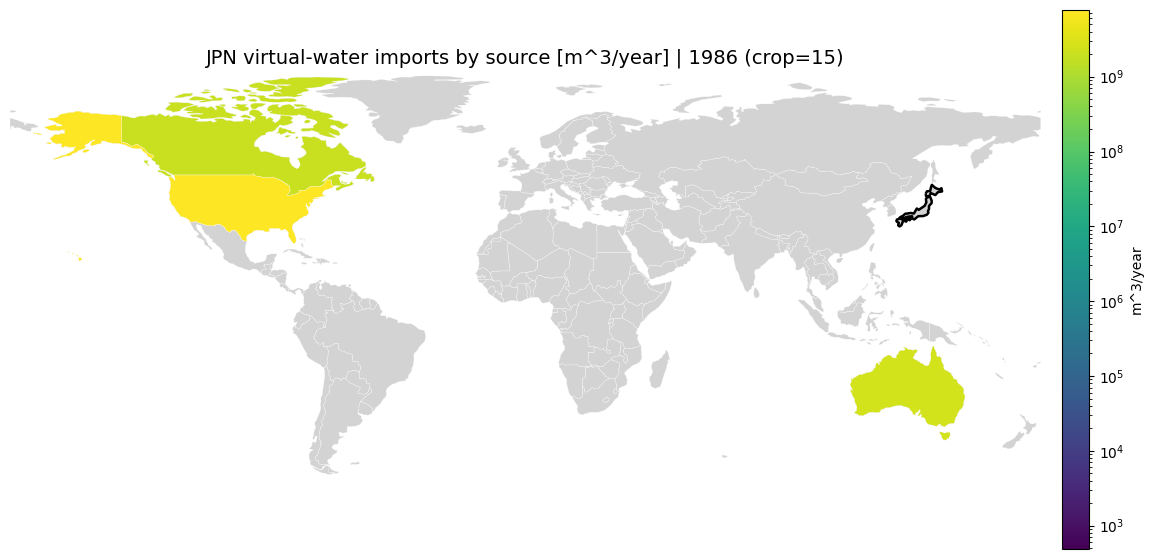

In [13]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation

def _normalize_zip_shp_path(p: str) -> str:
    """
    gpd.read_file() が読めるように、"xxx.zip!yyy.shp" を "zip://xxx.zip!yyy.shp" に寄せる。
    すでに zip:// が付いてたらそのまま。
    """
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def animate_vwt_imports_by_source(
    importer_iso3: str,
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,     # r"...\VWT_npy\VWT_{crop}_{year}.npy"
    ne_countries_shp: str,     # r"...\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"
    use_log: bool = True,
    xlim=(-180, 180),
    ylim=(-60, 85),
    unit="m^3/year",
    fps: int = 6,
    interval_ms: int | None = None,  # Noneならfpsから自動
    out_mp4: str | None = None,      # 例: r"C:\...\HKG_crop15_1986_2016.mp4"
    out_gif: str | None = None,      # 例: r"C:\...\HKG_crop15_1986_2016.gif"
    dpi: int = 150,
    top_n_print: int = 10,
):
    """
    - importer_iso3, crop は固定
    - year_start..year_end をアニメ化
    - カラーバーは全期間で固定スケール（global vmin/vmax）
    """
    importer_iso3 = str(importer_iso3).strip().upper()
    years = list(range(int(year_start), int(year_end) + 1))
    if interval_ms is None:
        interval_ms = int(1000 / max(1, fps))

    # -------------------------
    # 1) country_list & importer index
    # -------------------------
    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
            iso3_col = c
            break
    if iso3_col is None:
        for c in cl.columns:
            if "iso3" in str(c).strip().lower():
                iso3_col = c
                break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    # N はVWTのサイズに合わせたいので、まず最初の年を読んでN確定
    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    N = vwt0.shape[0]
    if vwt0.shape[0] != vwt0.shape[1]:
        print(f"[WARN] VWTmat is not square: {vwt0.shape}. row/colの向きを要確認")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    hit = clN.index[clN["_iso3"] == importer_iso3]
    if len(hit) == 0:
        raise ValueError(
            f"importer_iso3={importer_iso3} が country_list の先頭N行に見つからない。\n"
            f"・country_listがVWT順になっているか\n"
            f"・ISO3列の中身が正しいか\n"
            f"・importer_iso3の表記(USA/JPNなど)が正しいか を確認して。"
        )
    importer_index = int(hit[0])
    print("Importer index:", importer_index, f"(iso3={importer_iso3})")
    print("N:", N)

    # -------------------------
    # 2) world map load
    # -------------------------
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world["_iso3"] = world["ISO_A3"].astype(str).str.strip().str.upper()
    world.loc[world["_iso3"].isin(["-99", "NAN", "NONE", ""]), "_iso3"] = np.nan

    # importer boundary 用（固定）
    tgt_geom = world.loc[world["_iso3"] == importer_iso3]
    if len(tgt_geom) == 0:
        print("[WARN] importer が地図側で見つからない（ISO_A3にその国が無い/特殊コードの可能性）")

    # -------------------------
    # 3) preload imports (all years) + global vmin/vmax
    # -------------------------
    imports_by_year = {}
    global_pos_vals = []

    for y in years:
        vwt_path = vwt_npy_template.format(crop=crop, year=y)
        VWTmat = np.load(vwt_path).astype(float)
        if VWTmat.shape[0] != N or VWTmat.shape[1] != N:
            raise ValueError(f"年{y}のVWTサイズが一致しない: {VWTmat.shape} (expected {N}x{N})")

        # ★輸入：列（importer_index）を抜く
        imports = VWTmat[:, importer_index].astype(float)
        imports_by_year[y] = imports

        pos = imports[imports > 0]
        if pos.size > 0:
            global_pos_vals.append(pos)

    if len(global_pos_vals) == 0:
        raise ValueError("[ERROR] 全年で import>0 が1つも無い（row/colの向き、crop/year、importer_indexなど要確認）")

    global_pos_vals = np.concatenate(global_pos_vals)
    vmin = float(np.min(global_pos_vals))
    vmax = float(np.max(global_pos_vals))
    if vmin <= 0:
        # LogNormはvmin>0必須
        vmin = float(np.min(global_pos_vals[global_pos_vals > 0]))

    print(f"Global scale: vmin={vmin:g}, vmax={vmax:g} (use_log={use_log})")

    if use_log:
        norm = LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # -------------------------
    # 4) figure & fixed colorbar
    # -------------------------
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()

    sm = ScalarMappable(norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(unit)

    # -------------------------
    # 5) animation update
    # -------------------------
    def update(frame_i: int):
        y = years[frame_i]
        ax.cla()
        ax.set_axis_off()
        ax.set_title(
            f"{importer_iso3} virtual-water imports by source [{unit}] | {y} (crop={crop})",
            fontsize=14
        )

        imports = imports_by_year[y]
        src = pd.DataFrame({"iso3": clN["_iso3"].values, "import": imports})

        if top_n_print and top_n_print > 0 and frame_i == 0:
            src_pos = src[src["import"] > 0].sort_values("import", ascending=False)
            print("\nTop sources in first frame:")
            print(src_pos.head(top_n_print))

        m = world.merge(src, left_on="_iso3", right_on="iso3", how="left")

        # base
        m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

        pos = m["import"].fillna(0) > 0
        if pos.any():
            m.loc[pos].plot(
                ax=ax,
                column="import",
                norm=norm,              # ★固定スケール
                linewidth=0.2,
                edgecolor="white",
                legend=False,
            )

        # importer boundary
        if len(tgt_geom) > 0:
            tgt_geom.boundary.plot(ax=ax, linewidth=1.8, color="black")

        # ★ガタガタ防止：座標系を毎フレーム固定
        ax.set_aspect("equal")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        return []

    anim = FuncAnimation(
        fig,
        update,
        frames=len(years),
        interval=interval_ms,
        blit=False
    )

    # -------------------------
    # 6) save (optional)
    # -------------------------
    if out_mp4:
        # mp4保存はffmpegが必要
        anim.save(
            out_mp4,
            writer="ffmpeg",
            fps=fps,
            dpi=dpi,
            savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0.05},
        )
        print("Saved MP4:", out_mp4)

    if out_gif:
        anim.save(
            out_gif,
            fps=fps,
            dpi=dpi,
            savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0.05},
        )
        print("Saved GIF:", out_gif)

    #plt.show()
    return anim


# =========================
# 使い方（ここだけ変えればOK）
# =========================
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

anim = animate_vwt_imports_by_source(
    importer_iso3="JPN",
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    use_log=True,
    fps=6,
    out_gif=r"C:\修論研究\VWT_historical_data\JPN_crop15_1986_2016_import.gif",
)